<a href="https://colab.research.google.com/github/codehacker4655/ML-with-theory-inform-of-comments-/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
%matplotlib inline

In [2]:
df=pd.read_csv('Travel.csv')

In [3]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [5]:
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean(),4),'% missing values')


Age 0.0462 % missing values
TypeofContact 0.0051 % missing values
DurationOfPitch 0.0514 % missing values
NumberOfFollowups 0.0092 % missing values
PreferredPropertyStar 0.0053 % missing values
NumberOfTrips 0.0286 % missing values
NumberOfChildrenVisiting 0.0135 % missing values
MonthlyIncome 0.0477 % missing values


In [6]:
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [7]:
df.PreferredPropertyStar.unique()

array([ 3.,  4.,  5., nan])

In [8]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [9]:
discrete=[column for column in df.columns if len(df[column].unique())<25 and df[column].dtype!='O']

In [10]:
continuous=[column for column in df.columns if df[column].dtype!='O']

In [11]:
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)

In [12]:
df['TypeofContact'].unique()

array(['Self Enquiry', 'Company Invited', nan], dtype=object)

In [13]:
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)

<Axes: xlabel='Age', ylabel='Density'>

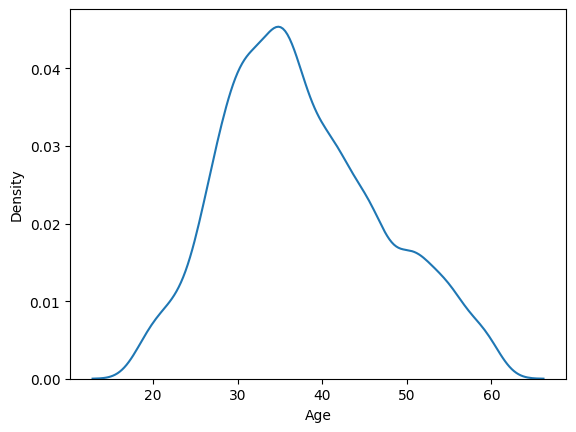

In [14]:
sns.kdeplot(df['Age'])

In [15]:
df['Age'].mean()

np.float64(37.62226512226512)

In [16]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

In [17]:
df['DurationOfPitch'].unique()

array([  6.,  14.,   8.,   9.,  30.,  29.,  33.,  22.,  21.,  32.,  25.,
        27.,  11.,  17.,  15.,  13.,  12.,  16.,  10.,  31.,  18.,  nan,
        24.,  35.,  28.,  20.,  26.,  34.,  23.,   5.,  19., 126.,   7.,
        36., 127.])

<Axes: xlabel='DurationOfPitch', ylabel='Density'>

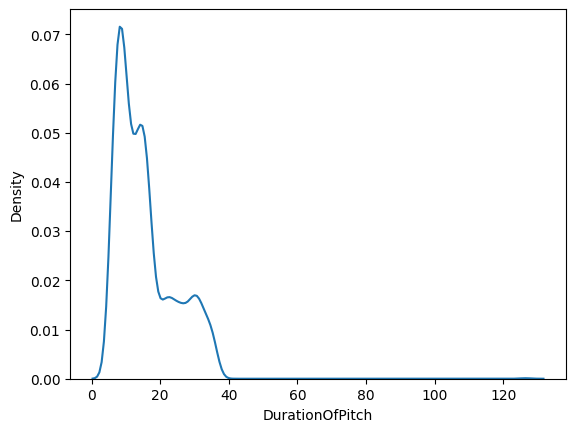

In [18]:
sns.kdeplot(df['DurationOfPitch'])

In [19]:
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(),inplace=True)

<Axes: xlabel='NumberOfFollowups', ylabel='Density'>

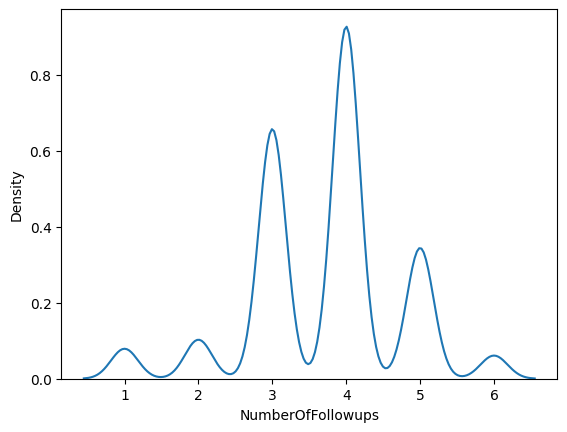

In [20]:
sns.kdeplot(df['NumberOfFollowups'])

In [21]:
df['NumberOfFollowups'].unique()

array([ 3.,  4.,  2.,  5., nan,  1.,  6.])

In [22]:
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0],inplace=True)

<Axes: xlabel='NumberOfTrips', ylabel='Density'>

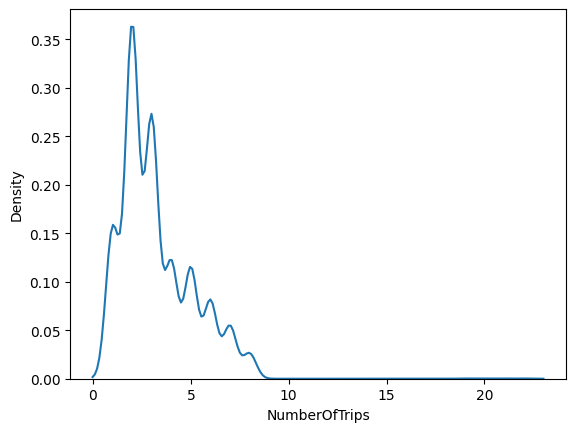

In [23]:
sns.kdeplot(df['NumberOfTrips'])

In [24]:
df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(),inplace=True)

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

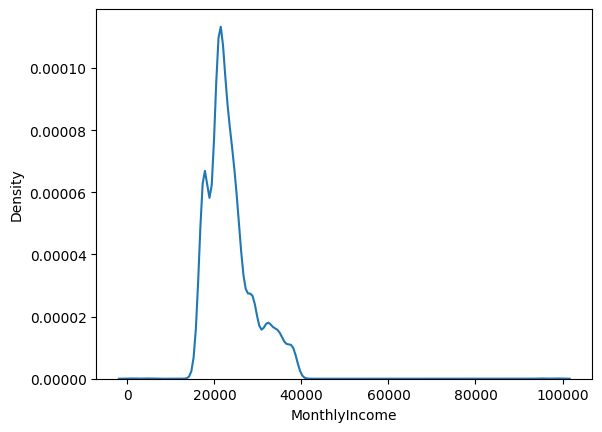

In [25]:
sns.kdeplot(df['MonthlyIncome'])

In [26]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(),inplace=True)

In [27]:
df['NumberOfChildrenVisiting'].unique()

array([ 0.,  2.,  1., nan,  3.])

<Axes: xlabel='NumberOfChildrenVisiting', ylabel='Density'>

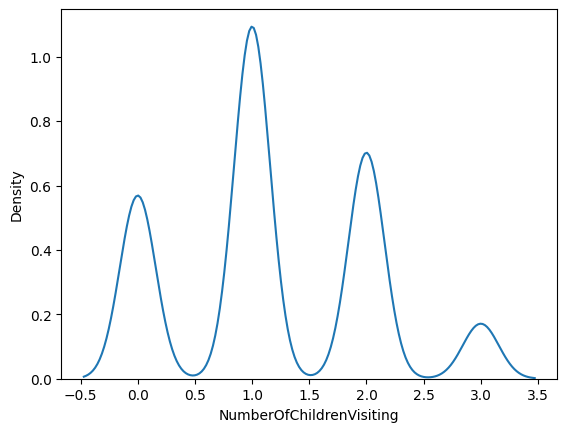

In [28]:
sns.kdeplot(df['NumberOfChildrenVisiting'])

In [29]:
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0],inplace=True)

In [30]:
df[["ProdTaken","NumberOfChildrenVisiting"]].corr()

,ProdTaken,NumberOfChildrenVisiting
ProdTaken,1.000000,0.008009
NumberOfChildrenVisiting,0.008009,1.000000


In [31]:
#df['Gender']=df['Gender'].replace('Fe Male','Female')
# ------------------------------------------------------------
# Difference between .replace() and .str.replace() in Pandas
# ------------------------------------------------------------

# 1) .replace()
#    - Used when you want to replace entire values in a column.
#    - Example: changing "Male" to "M" and "Female" to "F".
#    - Think of it as "whole value replacement".
#    Example:
#    df['gender'] = df['gender'].replace({'Male': 'M', 'Female': 'F'})

# 2) .str.replace()
#    - Used when you want to replace only part of the string inside values.
#    - Works like string/regex replacement.
#    - Example: removing "ale" from "Male".
#    - Think of it as "inside value replacement".
#    Example:
#    df['gender'] = df['gender'].str.replace('ale', '')

# ------------------------------------------------------------
# Quick examples if column = ["Male", "Female", "Other"]:
#    Using .replace({'Male': 'M'})      -> ["M", "Female", "Other"]
#    Using .str.replace("ale", "")      -> ["M", "Fm", "Other"]
# ------------------------------------------------------------

# In short:
# - Use .replace()       -> when replacing entire values.
# - Use .str.replace()   -> when replacing part of strings inside values.
# ------------------------------------------------------------

In [32]:
df.drop('CustomerID',inplace=True,axis=1)

In [33]:
df['MaritalStatus'].unique()
df['MaritalStatus']=np.where(df['MaritalStatus']=='Unmarried','Single',df['MaritalStatus'])

In [34]:
df['MaritalStatus'].unique()

array(['Single', 'Divorced', 'Married'], dtype=object)

In [35]:
df[df.duplicated()]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
1514,0,37.622265,Company Invited,1,6.0,Small Business,Female,2,3.0,Deluxe,3.0,Single,2.0,0,3,1,0.0,Manager,22347.0
1518,0,46.000000,Company Invited,3,11.0,Small Business,Male,3,3.0,Deluxe,3.0,Single,5.0,1,5,1,1.0,Manager,20772.0
1531,0,38.000000,Company Invited,1,35.0,Salaried,Female,2,3.0,Deluxe,3.0,Single,2.0,0,3,1,0.0,Manager,17406.0
1532,0,50.000000,Self Enquiry,1,13.0,Small Business,Female,2,4.0,King,3.0,Married,6.0,1,4,1,1.0,VP,33740.0
1536,0,36.000000,Company Invited,1,17.0,Salaried,Male,3,4.0,Deluxe,4.0,Single,2.0,0,4,1,1.0,Manager,21499.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760,0,36.000000,Self Enquiry,1,9.0,Salaried,Male,3,5.0,Standard,4.0,Married,4.0,0,4,1,1.0,Senior Manager,28952.0
4788,0,31.000000,Self Enquiry,1,14.0,Salaried,Male,3,4.0,Deluxe,3.0,Married,3.0,0,5,1,2.0,Manager,22169.0
4789,0,45.000000,Self Enquiry,1,36.0,Salaried,Male,3,4.0,Deluxe,3.0,Single,3.0,0,5,1,2.0,Manager,23219.0
4793,0,61.000000,Self Enquiry,3,14.0,Small Business,Male,3,2.0,Deluxe,3.0,Married,2.0,1,5,0,1.0,Manager,23898.0


In [36]:
df['Occupation'].unique()

array(['Salaried', 'Free Lancer', 'Small Business', 'Large Business'],
      dtype=object)

In [37]:
num=[column for column in df.columns if df[column].dtype=="O"]

In [38]:
cat=[column for column in df.columns if df[column].dtype!="O"]

In [39]:
num

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [40]:
cat

['ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [41]:
for i in num:
    print(i)
    print(df[i].unique())


TypeofContact
['Self Enquiry' 'Company Invited']
Occupation
['Salaried' 'Free Lancer' 'Small Business' 'Large Business']
Gender
['Female' 'Male' 'Fe Male']
ProductPitched
['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']
MaritalStatus
['Single' 'Divorced' 'Married']
Designation
['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']


In [42]:
df['Gender'].unique()

array(['Female', 'Male', 'Fe Male'], dtype=object)

In [43]:
df["ProductPitched"].unique()

array(['Deluxe', 'Basic', 'Standard', 'Super Deluxe', 'King'],
      dtype=object)

In [44]:
df['Gender'].value_counts()

,count
Gender,
Male,2916
Female,1817
Fe Male,155


In [45]:
df['Gender']=np.where(df['Gender']=='Fe Male','Female',df['Gender'])

In [46]:
# create new column for feature
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], axis=1, inplace=True)

In [47]:
from sklearn.model_selection import train_test_split
x=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [48]:
cat_features=x.select_dtypes(include='object').columns
num_features=x.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_tranformer=StandardScaler()
oh_transform=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer([("OneHotEncoder",oh_transform,cat_features),("StandardScaler",numeric_tranformer,num_features)])

In [49]:
# ==========================================================
# 📌 ColumnTransformer in sklearn
# ==========================================================
# A ColumnTransformer is a tool in sklearn that allows us to apply
# DIFFERENT preprocessing steps to DIFFERENT columns in a dataset.
#
# Why do we need it?
# -------------------
# In real datasets, we often have MIXED data types:
#   - Numerical features (Age, Salary, Marks, etc.)
#   - Categorical features (Gender, City, Country, etc.)
#
# For numerical features -> We may want to scale or normalize them (e.g., StandardScaler)
# For categorical features -> We may want to encode them (e.g., OneHotEncoder, OrdinalEncoder)
#
# Problem without ColumnTransformer:
# -----------------------------------
# - If we apply transformations separately, we need to handle multiple pipelines,
#   merge results back, and risk mismatching columns.
# - This becomes messy and error-prone when there are many preprocessing steps.
#
# Solution:
# ----------
# ColumnTransformer allows us to define preprocessing for each group of columns
# in a clean, single object.
# It automatically applies the right transformation to the right columns,
# and concatenates the results into one transformed dataset.
#
# ==========================================================
# 📌 Example 1: Using ColumnTransformer
# ==========================================================

#import pandas as pd
#from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import StandardScaler, OneHotEncoder
#from sklearn.linear_model import LogisticRegression
#from sklearn.pipeline import Pipeline

# Sample dataset
#data = pd.DataFrame({
#    'Age': [25, 30, 35, 40],
#    'Salary': [50000, 60000, 70000, 80000],
#    'City': ['Delhi', 'Mumbai', 'Delhi', 'Bangalore'],
#    'Purchased': [0, 1, 0, 1]
#})

# Independent features
#X = data[['Age', 'Salary', 'City']]
# Target
#y = data['Purchased']

# Define ColumnTransformer
# - Scale numerical features ("Age", "Salary")
# - One-hot encode categorical feature ("City")
#preprocessor = ColumnTransformer(
#    transformers=[
#        ('num', StandardScaler(), ['Age', 'Salary']),     # apply StandardScaler to Age and Salary
#        ('cat', OneHotEncoder(), ['City'])                # apply OneHotEncoder to City
#    ]
#)

# Create a pipeline with preprocessing + model
#pipeline = Pipeline(steps=[
#    ('preprocessor', preprocessor),
#    ('classifier', LogisticRegression())
#])

# Fit pipeline
#pipeline.fit(X, y)

# Predict
#print(pipeline.predict(X))

# ==========================================================
# 📌 Explanation of Workflow:
# ==========================================================
# 1. ColumnTransformer is created with "transformers":
#       ('num', StandardScaler(), ['Age', 'Salary'])
#         -> applies StandardScaler ONLY to "Age" and "Salary"
#
#       ('cat', OneHotEncoder(), ['City'])
#         -> applies OneHotEncoder ONLY to "City"
#
# 2. After transformation:
#       - Age & Salary become scaled values (mean=0, std=1)
#       - City becomes multiple columns (one-hot encoded)
#
# 3. ColumnTransformer automatically combines them into ONE dataset
#
# 4. Pipeline ensures:
#       - Preprocessing happens first
#       - Then model (LogisticRegression) is applied
#
# Benefit:
# --------
# - Clean, modular, no risk of column mismatch
# - Useful for ML projects where you have mixed data types
# - Works well in cross-validation and GridSearchCV
#
# ==========================================================
# 📌 Example 2: Apply different scalers to different columns
# ==========================================================

#from sklearn.preprocessing import MinMaxScaler

# Suppose we want:
# - Age -> StandardScaler
# - Salary -> MinMaxScaler
# - City -> OneHotEncoder
#preprocessor2 = ColumnTransformer(
#    transformers=[
#        ('age_scaler', StandardScaler(), ['Age']),
#        ('salary_scaler', MinMaxScaler(), ['Salary']),
#        ('city_encoder', OneHotEncoder(), ['City'])
#    ]
#)

# Fit_transform data
#print(preprocessor2.fit_transform(X))

# ==========================================================
# 📌 Where to use ColumnTransformer?
# ==========================================================
# - Any dataset with mixed data types (numerical + categorical)
# - When we want different preprocessing for different features
# - When building ML pipelines for production-level ML systems
# - Helps automate preprocessing + avoid manual merging

In [50]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(drop='first'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object'))])

In [51]:
x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.transform(x_test)

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score,roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [53]:
# ===========================================
# Complex Decision Tree Example (Classification)
# ===========================================

# Dataset:
# Predict: Buys Laptop (Yes/No)
# Features: Age Group, Student, Credit Rating

# | Age Group | Student | Credit Rating | Buys Laptop |
# |-----------|--------|---------------|-------------|
# | Youth     | Yes    | Fair          | Yes         |
# | Youth     | Yes    | Excellent     | No          |
# | Middle    | Yes    | Fair          | Yes         |
# | Senior    | No     | Fair          | No          |
# | Senior    | No     | Excellent     | Yes         |
# | Senior    | Yes    | Excellent     | Yes         |
# | Middle    | No     | Excellent     | No          |
# | Youth     | No     | Fair          | No          |
# | Youth     | No     | Excellent     | Yes         |
# | Senior    | Yes    | Fair          | Yes         |

# Step 1: Calculate root impurity (Gini)
# Total Yes = 6, No = 4
# Gini_root = 1 - (p_yes^2 + p_no^2) = 1 - (0.6^2 + 0.4^2) = 0.48

# Step 2: Consider splitting by each feature
# Feature: Student (Yes/No)
# Student = Yes -> Subset = [Yes, No, Yes, Yes, Yes] -> 4 Yes, 1 No -> Gini = 0.32
# Student = No  -> Subset = [No, No, No, Yes]          -> 1 Yes, 3 No -> Gini = 0.375
# Weighted Gini = 0.5*0.32 + 0.5*0.375 = 0.3475 (best so far)

# Feature: Age Group (Youth, Middle, Senior)
# Youth -> [Yes, No, No, Yes] -> 2 Yes, 2 No -> Gini = 0.5
# Middle -> [Yes, No]          -> 1 Yes, 1 No -> Gini = 0.5
# Senior -> [No, Yes, Yes, Yes] -> 3 Yes, 1 No -> Gini = 0.375
# Weighted Gini = 0.2 + 0.1 + 0.15 = 0.45 (worse than Student)

# Feature: Credit Rating (Fair, Excellent)
# Fair -> [Yes, Yes, No, Yes] -> 3 Yes, 1 No -> Gini = 0.375
# Excellent -> [No, Yes, No, Yes, Yes] -> 3 Yes, 2 No -> Gini = 0.48
# Weighted Gini = 0.15 + 0.24 = 0.39 (worse than Student)

# Step 3: Choose best split at root
# -> Student feature gives lowest weighted Gini = 0.3475
# Root node split: Student = Yes?

# Step 4: Split branches further
# Left branch: Student = Yes (Subset: [Yes, No, Yes, Yes, Yes])
# - Features left: Age Group, Credit Rating
# - Split by Age Group:
#   Youth -> [Yes, No] -> Gini = 0.5
#   Middle -> [Yes] -> Pure -> Gini = 0
#   Senior -> [Yes, Yes] -> Pure -> Gini = 0
# Weighted Gini = 0.2 -> good improvement
# So left branch next split: Age Group

# Right branch: Student = No (Subset: [No, No, No, Yes])
# - Features left: Age Group, Credit Rating
# - Split by Credit Rating:
#   Fair -> [No, No] -> Pure -> Gini = 0
#   Excellent -> [No, Yes] -> Gini = 0.5
# Weighted Gini = 0.25 -> improvement
# Right branch next split: Credit Rating

# Step 5: Final Tree (simplified)
# Student?
#  ├── Yes
#  │    └── Age Group?
#  │         ├── Youth -> Mostly Yes/No (leaf)
#  │         ├── Middle -> Yes (leaf)
#  │         └── Senior -> Yes (leaf)
#  └── No
#       └── Credit Rating?
#            ├── Fair -> No (leaf)
#            └── Excellent -> Mixed (leaf)

# Notes:
# - Categorical feature > 2 categories: algorithm tries all possible groupings to reduce impurity
# - Weighted Gini used to decide best split
# - Tree grows recursively until all nodes pure or stopping criteria reached
# - Conflicting examples may lead to “mostly Yes/No” leaves

In [54]:
#efficient way of learning model and remember guys , we cannot be just dependent on one model


In [55]:
# ===========================================
# Random Forest Training Process
# ===========================================

# 1️⃣ What is Random Forest?
# - Ensemble of decision trees
# - Uses bagging (bootstrap aggregation) to reduce variance
# - Each tree trained on different random subset of data and features
# - Classification: majority vote
# - Regression: average of predictions

# 2️⃣ Training Steps

# Step 1: Generate Bootstrap Samples
# - Original dataset: size N
# - For each tree, pick N samples randomly with replacement
# - Some rows may repeat, some may be missing
# - This ensures each tree sees slightly different data

# Example:
# Original Data: [Row1, Row2, Row3, Row4, Row5]
# Tree1 Sample:  [Row1, Row2, Row3, Row3, Row5]

# Step 2: Feature Subset Selection at Each Split
# - At each node, randomly pick 'max_features' features
# - Choose the best split among these features only
# - This decorrelates trees, increases diversity

# Example:
# Features = [Age, Student, Credit Rating]
# max_features = 2
# At a node, only 2 features are considered for best split

# Step 3: Build Decision Tree
# - Use standard decision tree logic:
#   1. Calculate impurity (Gini/Entropy for classification, MSE for regression)
#   2. Choose best split among sampled features
#   3. Split recursively until stopping criteria (max_depth, min_samples_leaf)
# - Trees in Random Forest are usually NOT pruned

# Step 4: Repeat for All Trees
# - Repeat steps 1–3 for n_estimators trees
# - Each tree slightly different due to bootstrap sampling and feature selection

# Step 5: Make Predictions
# - Classification: each tree votes → majority vote wins
# - Regression: each tree predicts → average of all trees

# Example for Classification (5 trees):
# Tree1: Yes
# Tree2: No
# Tree3: Yes
# Tree4: Yes
# Tree5: No
# Final Prediction = Yes (majority vote)

# 3️⃣ Advantages of Random Forest
# - Reduces overfitting compared to a single decision tree
# - Works well with high-dimensional data
# - Handles categorical and numerical features
# - Robust to noisy data

# 4️⃣ Summary Flow
# For each tree in Random Forest:
#     1. Draw bootstrap sample from dataset
#     2. Build tree:
#         - At each node:
#             - Randomly select subset of features
#             - Pick best split among them
#         - Repeat until stopping criteria
# After all trees are built:
#     - Classification: majority vote
#     - Regression: average prediction

In [57]:
# ================================================================
# 📌 RANDOM FOREST CLASSIFIER PARAMETERS — COMMENT CHEAT SHEET
# ================================================================

# 🔹 n_estimators
# Number of trees in the forest
# Default = 100
# ↑ Increase → more stable results, less variance, but slower
# ↓ Decrease → faster training, but less accurate

# 🔹 criterion
# Function to measure the quality of a split
# Options:
#   "gini" (default) → Gini Impurity
#   "entropy" → Information Gain
#   "log_loss" → like entropy, works well with probabilities

# 🔹 max_depth
# Maximum depth of each tree
# Default = None (grow until all leaves are pure → may overfit)
# Small value (e.g. 5–10) → prevents overfitting, simpler model

# 🔹 min_samples_split
# Minimum samples required to split an internal node
# Default = 2
# ↑ Higher → fewer splits, simpler trees, less overfit
# ↓ Lower → more splits, complex trees, risk of overfit

# 🔹 min_samples_leaf
# Minimum samples required to be in a leaf node
# Default = 1
# ↑ Higher → smoother decision boundary, less variance
# ↓ Lower → more specific rules, risk of overfit

# 🔹 max_features
# Number of features to consider at each split
# Options:
#   "sqrt" (default for classification) → sqrt(total_features)
#   "log2" → log2(total_features)
#   None → use all features
# Smaller values → more randomness, less correlation between trees

# 🔹 bootstrap
# Whether to sample data with replacement
# True (default) → each tree trained on random subset (better diversity)
# False → each tree trained on full dataset (less randomness)

# 🔹 random_state
# Controls randomness of sampling & feature selection
# Set to an integer (e.g., 42) → reproducible results
# None → different results each run

# 🔹 n_jobs
# Number of CPU cores to use
# Default = None (1 core)
# -1 → use all available cores (faster)

# ================================================================
# ✅ Summary — When to Tune?
# - If model overfits → reduce max_depth, increase min_samples_leaf
# - If model underfits → increase n_estimators, allow deeper trees
# - For speed → reduce n_estimators, max_depth, or set n_jobs=-1
# ================================================================

In [56]:
models={
    "Random Forest":RandomForestClassifier(),
    "logistic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier()

}
for name,model in models.items():
  model.fit(x_train,y_train)

  y_train_pred=model.predict(x_train)
  y_test_pred=model.predict(x_test)

  #Training set parameters
  model_train_accuracy=accuracy_score(y_train,y_train_pred)
  model_train_f1=f1_score(y_train,y_train_pred)
  model_train_precision=precision_score(y_train,y_train_pred)
  model_train_recall=recall_score(y_train,y_train_pred)
  model_train_roc=roc_auc_score(y_train,y_train_pred)

  #Test set parameters
  model_test_accuracy=accuracy_score(y_test,y_test_pred)
  model_test_f1=f1_score(y_test,y_test_pred)
  model_test_precision=precision_score(y_test,y_test_pred)
  model_test_recall=recall_score(y_test,y_test_pred)
  model_test_roc=roc_auc_score(y_test,y_test_pred)

  print(name)


  print('Model performance for Training set')
  print("- Accuracy: {:.4f}".format(model_train_accuracy))
  print('- F1 score: {:.4f}'.format(model_train_f1))

  print('- Precision: {:.4f}'.format(model_train_precision))
  print('- Recall: {:.4f}'.format(model_train_recall))
  print('- Roc Auc Score: {:.4f}'.format(model_train_roc))



  print('----------------------------------')

  print('Model performance for Test set')
  print('- Accuracy: {:.4f}'.format(model_test_accuracy))
  print('- F1 score: {:.4f}'.format(model_test_f1))
  print('- Precision: {:.4f}'.format(model_test_precision))
  print('- Recall: {:.4f}'.format(model_test_recall))
  print('- Roc Auc Score: {:.4f}'.format(model_test_roc))


  print('='*35)
  print('\n')

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9202
- F1 score: 0.7516
- Precision: 0.9593
- Recall: 0.6178
- Roc Auc Score: 0.8057


logistic Regression
Model performance for Training set
- Accuracy: 0.8460
- F1 score: 0.4245
- Precision: 0.7003
- Recall: 0.3045
- Roc Auc Score: 0.6373
----------------------------------
Model performance for Test set
- Accuracy: 0.8364
- F1 score: 0.4118
- Precision: 0.6914
- Recall: 0.2932
- Roc Auc Score: 0.6307


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9233
- F1 score: 0.7956
- Precision: 0.8295
- Recall: 0.7644
- Roc Auc Score: 0.8631




In [58]:
rf_para={
    "max_depth":[5,8,None,10],
    "max_features":[5,7,"auto",8],
    "min_samples_split":[2,8,15,20],
    "n_estimators":[100,200,300]
}


In [59]:
randomcv_models=[
    ('RF',RandomForestClassifier(),rf_para)
]

In [60]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 300]})]

In [61]:
from sklearn.model_selection import RandomizedSearchCV
model_param={}
for name,model,params in randomcv_models:
  random=RandomizedSearchCV(estimator=model,param_distributions=params,n_iter=100,cv=3,verbose=2,n_jobs=-1)
  random.fit(x_train,y_train)
  model_param[name]=random.best_params_

for model_name in model_param:
  print(f"{model_name}---->{model_param[model_name]}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
RF---->{'n_estimators': 200, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


In [62]:
models={
    "Random Forest":RandomForestClassifier(n_estimators=200,min_samples_leaf=2,max_features=7,max_depth=None),


}
for name,model in models.items():
  model.fit(x_train,y_train)

  y_train_pred=model.predict(x_train)
  y_test_pred=model.predict(x_test)

  #Training set parameters
  model_train_accuracy=accuracy_score(y_train,y_train_pred)
  model_train_f1=f1_score(y_train,y_train_pred)
  model_train_precision=precision_score(y_train,y_train_pred)
  model_train_recall=recall_score(y_train,y_train_pred)
  model_train_roc=roc_auc_score(y_train,y_train_pred)

  #Test set parameters
  model_test_accuracy=accuracy_score(y_test,y_test_pred)
  model_test_f1=f1_score(y_test,y_test_pred)
  model_test_precision=precision_score(y_test,y_test_pred)
  model_test_recall=recall_score(y_test,y_test_pred)
  model_test_roc=roc_auc_score(y_test,y_test_pred)

  print(name)


  print('Model performance for Training set')
  print("- Accuracy: {:.4f}".format(model_train_accuracy))
  print('- F1 score: {:.4f}'.format(model_train_f1))

  print('- Precision: {:.4f}'.format(model_train_precision))
  print('- Recall: {:.4f}'.format(model_train_recall))
  print('- Roc Auc Score: {:.4f}'.format(model_train_roc))



  print('----------------------------------')

  print('Model performance for Test set')
  print('- Accuracy: {:.4f}'.format(model_test_accuracy))
  print('- F1 score: {:.4f}'.format(model_test_f1))
  print('- Precision: {:.4f}'.format(model_test_precision))
  print('- Recall: {:.4f}'.format(model_test_recall))
  print('- Roc Auc Score: {:.4f}'.format(model_test_roc))


  print('='*35)
  print('\n')

Random Forest
Model performance for Training set
- Accuracy: 0.9923
- F1 score: 0.9790
- Precision: 0.9986
- Recall: 0.9602
- Roc Auc Score: 0.9800
----------------------------------
Model performance for Test set
- Accuracy: 0.9110
- F1 score: 0.7203
- Precision: 0.9333
- Recall: 0.5864
- Roc Auc Score: 0.7881


